Today's topics:
* what's actually inside the Materials Project
* loading a live-database export the exact same way you load any other CSV
* `.head()`, `.describe()`, one histogram, one scatter -- same tools, a much bigger table

> By the end of today you should be able to complete Problem 5 of Homework 4

# You already know how to do this

*What if the code you wrote last week works, unchanged, on a research-grade database with
150,000+ materials in it?*

The Materials Project is a U.S. Department of Energy-funded database that runs quantum-mechanical
(DFT) calculations on essentially every known and hypothesized inorganic crystal structure, and
publishes the results for free. By the end of today you'll have pulled real DFT data on a family
of lithium-iron-oxide compounds -- battery cathode materials -- and looked at it with exactly the
tools from last week.

# What's in the Materials Project?

Every entry looks like a row you've already seen: a formula, a crystal structure, a formation
energy, a band gap, a density. Take a look at [mp-19017](https://materialsproject.org/materials/mp-19017)
(LiFeO2) on the site -- same *kinds* of columns you've been summarizing with `.describe()` all
along.

No lab on Earth could synthesize and characterize 150,000 compounds one at a time. That's the
whole reason computed databases plus a few `pandas` skills matter.

# Load the dataset

## Dataset: Materials Project Li-Fe-O Teaser

A small cached export from the Materials Project `summary` endpoint, restricted to the
Li-Fe-O chemical system: pure elements (Fe), binary oxides, and ternary compounds relevant to
battery cathode chemistry (e.g. LiFeO2, LiFePO4-family relatives). Columns:
`material_id`, `formula_pretty`, `nelements`, `nsites`, `crystal_system`, `density`,
`formation_energy_per_atom`, `band_gap`, `energy_above_hull` -- see
`outlines/Lecture10_materials-project-teaser-real-data-from-a-real-dat.md` for the full field
spec and rationale.

388 compounds: 47 pure elements, 165 binary oxides, 176 ternary Li-Fe-O compounds.
Generated 2026-08-08 from the Materials Project summary endpoint (all subsystems of Li-Fe-O).

In [1]:
import os
import pandas as pd

_file = 'mp_lifeo_teaser.csv'
_github = f'https://raw.githubusercontent.com/wfreinhart/matse219/main/datasets/{_file}'
_local = next(
    (p for p in (f'datasets/{_file}', f'../datasets/{_file}', f'../../datasets/{_file}', f'../../../datasets/{_file}')
     if os.path.exists(p)),
    None,
)

if _local:
    data = pd.read_csv(_local)
else:
    try:
        data = pd.read_csv(_github)
    except Exception as e:
        raise RuntimeError(
            f"Could not find '{_file}' locally, and it is not yet published at {_github} "
            "either. This dataset is BLOCKED: it needs a Materials Project API key, which "
            "was not available when this course was drafted. To fix this, from the repo "
            "root run:\n\n"
            "    MP_API_KEY=your_key_here .venv/bin/python bin/generate_mp_teaser.py\n\n"
            "(get a free key at https://materialsproject.org/api), which writes "
            "datasets/mp_lifeo_teaser.csv. Then re-run this cell."
        ) from e
data

,material_id,formula_pretty,nelements,nsites,crystal_system,density,formation_energy_per_atom,band_gap,energy_above_hull
0,mp-13,Fe,1,2,Cubic,7.902858,0.000000,0.0000,0.000000
1,mp-51,Li,1,1,Cubic,0.566455,0.001672,0.0000,0.001672
2,mp-135,Li,1,1,Cubic,0.566613,0.009651,0.0000,0.009651
3,mp-136,Fe,1,2,Hexagonal,9.407744,0.097806,0.0000,0.097806
4,mp-150,Fe,1,1,Cubic,7.593374,0.148365,0.0000,0.148365
...,...,...,...,...,...,...,...,...,...
383,mp-2411688,LiFe2O3,3,6,Monoclinic,4.555689,-1.730409,0.7529,0.060056
384,mp-2421172,O2,1,6,Trigonal,1.259793,0.916266,2.7642,0.916266
385,mp-2739215,O2,1,8,Monoclinic,1.484854,0.012019,2.6680,0.012019
386,mp-2767639,FeO,2,8,Monoclinic,6.094629,-1.251460,0.0000,0.109320


388 compounds from the Li-Fe-O chemical system -- pure elements (Fe), binary oxides, and ternary
compounds like LiFeO2 that show up in cathode chemistry. Columns: `material_id`, `formula_pretty`,
`nelements`, `nsites`, `crystal_system`, `density`, `formation_energy_per_atom`, `band_gap`,
`energy_above_hull`.

This CSV is nothing more than a `summary.search()` API call someone already ran and saved to
disk -- same shape of file as every dataset you've loaded so far this semester.

# Where this CSV actually came from

This part is instructor-only -- don't run it, there's no shared API key for 60 people to hit at
once. Here's the call that produced `data` above:

```python
from mp_api.client import MPRester

with MPRester(api_key="INSTRUCTOR_KEY") as mpr:
    docs = mpr.summary.search(
        chemsys="Li-Fe-O",
        fields=["material_id", "formula_pretty", "nelements", "nsites",
                "density", "formation_energy_per_atom", "band_gap",
                "energy_above_hull", "symmetry"]
    )
```

`docs` converts into the exact same table shape as the CSV you just loaded. Everyone can get a
free API key in about two minutes at [materialsproject.org/api](https://materialsproject.org/api)
-- we'll actually use one in Module 3.

# `.head()` and `.describe()` on real DFT data

In [2]:
data.head(10)

,material_id,formula_pretty,nelements,nsites,crystal_system,density,formation_energy_per_atom,band_gap,energy_above_hull
0,mp-13,Fe,1,2,Cubic,7.902858,0.000000,0.0000,0.000000
1,mp-51,Li,1,1,Cubic,0.566455,0.001672,0.0000,0.001672
2,mp-135,Li,1,1,Cubic,0.566613,0.009651,0.0000,0.009651
3,mp-136,Fe,1,2,Hexagonal,9.407744,0.097806,0.0000,0.097806
4,mp-150,Fe,1,1,Cubic,7.593374,0.148365,0.0000,0.148365
5,mp-841,Li2O2,2,8,Hexagonal,2.414495,-1.650170,1.9743,0.000000
6,mp-1456,Fe2O3,2,160,Tetragonal,4.561836,-1.587731,1.5673,0.119360
7,mp-1960,Li2O,2,3,Cubic,1.969302,-2.061598,4.8986,0.000000
8,mp-10173,Li,1,2,Hexagonal,0.573292,0.005988,0.0000,0.005988
9,mp-12957,O2,1,8,Monoclinic,1.974484,0.000000,1.3316,0.000000


In [3]:
data.describe()

,nelements,nsites,density,formation_energy_per_atom,band_gap,energy_above_hull
count,388.000000,388.000000,388.000000,388.000000,388.000000,388.000000
mean,2.332474,26.896907,3.891695,-1.267174,0.598505,0.190197
std,0.682204,24.245827,1.377097,0.746029,0.861926,0.294968
min,1.000000,1.000000,0.181168,-2.061598,0.000000,0.000000
25%,2.000000,9.000000,3.055543,-1.728510,0.000000,0.056811
50%,2.000000,21.000000,4.012226,-1.528397,0.069700,0.094746
75%,3.000000,35.250000,4.845181,-1.154142,1.099550,0.185418
max,3.000000,160.000000,9.407744,1.880841,5.242200,2.382720


In [4]:
data['crystal_system'].value_counts()

crystal_system
Monoclinic      118
Triclinic        95
Orthorhombic     68
Trigonal         38
Cubic            26
Tetragonal       25
Hexagonal        18
Name: count, dtype: int64

A few things worth reading off that `.describe()` table:
* `band_gap` of exactly 0 eV means metallic/conducting; anything above 0 is an insulator or
  semiconductor
* `energy_above_hull` near 0 means thermodynamically stable -- more on what "hull" means in
  Module 3
* `formation_energy_per_atom` spans negative and positive values, same "spread of numbers"
  conversation as Lectures 4-6, just on a DFT-computed quantity this time

## [Check your understanding]

In the code cell below, use `.describe()` to find the mean `band_gap`. How many compounds have a
`band_gap` of exactly 0?

# One histogram, same tool

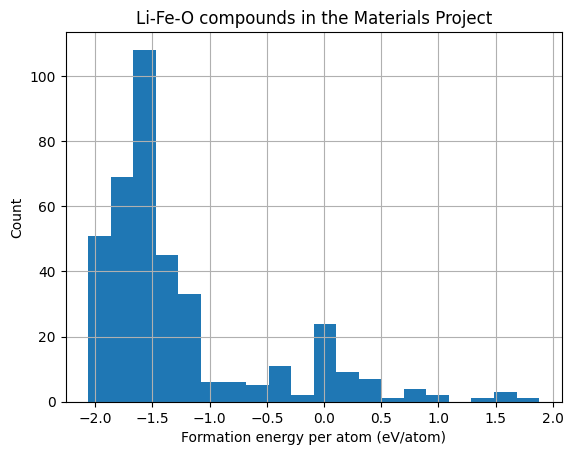

In [5]:
import matplotlib.pyplot as plt

data['formation_energy_per_atom'].hist(bins=20)
plt.xlabel('Formation energy per atom (eV/atom)')
plt.ylabel('Count')
plt.title('Li-Fe-O compounds in the Materials Project')
plt.show()

Describe the shape out loud -- skewed? clustered near zero? a long tail one direction? Negative
formation energy means it's energetically favorable to form that compound from its elements,
which is why most real compounds cluster below zero.

# One scatter, three variables

**Question:** does formation energy relate to band gap, and does stability track with either one?
That's three columns at once -- `plt.scatter`'s `c=` keyword can carry the third as color:

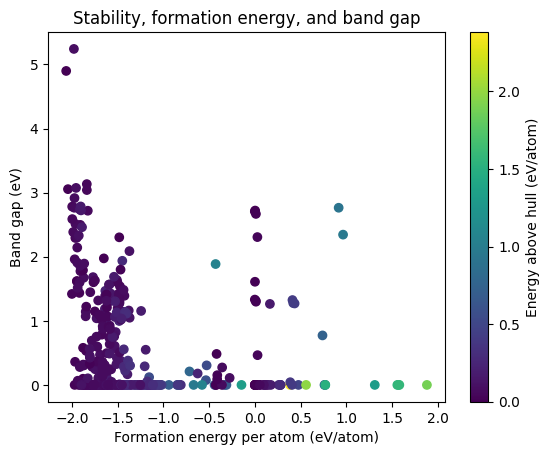

In [6]:
plt.scatter(data['formation_energy_per_atom'], data['band_gap'],
            c=data['energy_above_hull'], cmap='viridis')
plt.xlabel('Formation energy per atom (eV/atom)')
plt.ylabel('Band gap (eV)')
plt.colorbar(label='Energy above hull (eV/atom)')
plt.title('Stability, formation energy, and band gap')
plt.show()

Same `plt.scatter` call from last lecture, materials columns swapped in, plus a third variable
riding along as color -- a first taste of "more than two variables at once," which Lectures 24-26
will formalize properly.

## [Check your understanding]

In the code cell below, filter `data` to only compounds where `energy_above_hull` is 0
(thermodynamically stable). How many are there? Make a scatter of their formation energy vs. band
gap.

Four moves -- `read_csv`, `.head()`, `.describe()`, one plot -- just worked on a 150,000-compound
research database, no changes required. Homework 4 gives you the full `mp_lifeo_teaser.csv` and a
couple of guided questions. We'll come back to the Materials Project properly in Module 3 -- real
API queries, filtering, convex hulls, phase diagrams. Today was just a taste. Next time: comparisons
and logical indexing, the tool that makes "which compound has the lowest formation energy?" a
one-liner.